In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import (
    chi2_contingency,
    ttest_ind,
    mannwhitneyu,
    pointbiserialr
)

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv(
    "European_Bank_Retention_Scored.csv"
)

print("Dataset shape:", df.shape)

Dataset shape: (10000, 47)


In [3]:
ALPHA = 0.05

def significance_label(p_value):
    if p_value < ALPHA:
        return "Significant"
    else:
        return "Not Significant"

In [4]:
##Test 1 — Engagement Status vs Churn
engagement_table = pd.crosstab(
    df["Engagement_Status"],
    df["Exited"]
)

engagement_table

Exited,0,1
Engagement_Status,,
Active,4416,735
Inactive,3547,1302


In [5]:
chi2, p_value, dof, expected = chi2_contingency(
    engagement_table
)

print("Chi-Square Statistic:", round(chi2, 4))
print("p-value:", p_value)
print("Degrees of Freedom:", dof)

Chi-Square Statistic: 242.9853
p-value: 8.785858269303832e-55
Degrees of Freedom: 1


In [6]:
print(
    "Result:",
    significance_label(p_value)
)

Result: Significant


In [7]:
##Calculate Cramér's V
def cramers_v(table):
    
    chi2 = chi2_contingency(table)[0]
    
    n = table.to_numpy().sum()
    
    r, k = table.shape
    
    phi2 = chi2 / n
    
    phi2corr = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / (n - 1)
    )
    
    rcorr = r - (
        ((r - 1) ** 2) / (n - 1)
    )
    
    kcorr = k - (
        ((k - 1) ** 2) / (n - 1)
    )
    
    return np.sqrt(
        phi2corr /
        max(
            1e-12,
            min(
                kcorr - 1,
                rcorr - 1
            )
        )
    )

In [8]:
engagement_cramers_v = cramers_v(
    engagement_table
)

print(
    "Cramér's V:",
    round(engagement_cramers_v, 4)
)

Cramér's V: 0.1556


In [9]:
##Test 2 — Product Count vs Churn
product_table = pd.crosstab(
    df["NumOfProducts"],
    df["Exited"]
)

product_table

Exited,0,1
NumOfProducts,,
1,3675,1409
2,4242,348
3,46,220
4,0,60


In [10]:
chi2, p_value, dof, expected = chi2_contingency(
    product_table
)

print("Chi-Square Statistic:", round(chi2, 4))
print("p-value:", p_value)
print("Degrees of Freedom:", dof)
print("Result:", significance_label(p_value))

Chi-Square Statistic: 1503.6294
p-value: 0.0
Degrees of Freedom: 3
Result: Significant


In [11]:
print(
    "Cramér's V:",
    round(
        cramers_v(product_table),
        4
    )
)

Cramér's V: 0.3874


In [12]:
##Test 3 — Product Depth Group vs Churn
product_group_table = pd.crosstab(
    df["Product_Depth_Group"],
    df["Exited"]
)

product_group_table

Exited,0,1
Product_Depth_Group,,
3+ Products,46,280
Single Product,3675,1409
Two Products,4242,348


In [13]:
chi2, p_value, dof, expected = chi2_contingency(
    product_group_table
)

print("Chi-Square:", round(chi2, 4))
print("p-value:", p_value)
print("Result:", significance_label(p_value))
print(
    "Cramér's V:",
    round(
        cramers_v(product_group_table),
        4
    )
)

Chi-Square: 1494.6033
p-value: 0.0
Result: Significant
Cramér's V: 0.3864


In [14]:
##Test 4 — Credit Card Ownership vs Churn
card_table = pd.crosstab(
    df["HasCrCard"],
    df["Exited"]
)

card_table

Exited,0,1
HasCrCard,,
0,2332,613
1,5631,1424


In [15]:
chi2, p_value, dof, expected = chi2_contingency(
    card_table
)

print("Chi-Square:", round(chi2, 4))
print("p-value:", p_value)
print("Result:", significance_label(p_value))
print(
    "Cramér's V:",
    round(
        cramers_v(card_table),
        4
    )
)

Chi-Square: 0.4713
p-value: 0.49237236141554686
Result: Not Significant
Cramér's V: 0.0


In [16]:
##Test 5 — Geography vs Churn
geography_table = pd.crosstab(
    df["Geography"],
    df["Exited"]
)

chi2, p_value, dof, expected = chi2_contingency(
    geography_table
)

print("Chi-Square:", round(chi2, 4))
print("p-value:", p_value)
print("Result:", significance_label(p_value))
print(
    "Cramér's V:",
    round(
        cramers_v(geography_table),
        4
    )
)

Chi-Square: 301.2553
p-value: 3.8303176053541544e-66
Result: Significant
Cramér's V: 0.173


In [17]:
##Test 6 — Gender vs Churn
gender_table = pd.crosstab(
    df["Gender"],
    df["Exited"]
)

chi2, p_value, dof, expected = chi2_contingency(
    gender_table
)

print("Chi-Square:", round(chi2, 4))
print("p-value:", p_value)
print("Result:", significance_label(p_value))
print(
    "Cramér's V:",
    round(
        cramers_v(gender_table),
        4
    )
)

Chi-Square: 112.9186
p-value: 2.2482100097131755e-26
Result: Significant
Cramér's V: 0.1058


In [18]:
##Test 7 — Engagement Profile vs Churn
profile_table = pd.crosstab(
    df["Final_Engagement_Segment"],
    df["Exited"]
)

chi2, p_value, dof, expected = chi2_contingency(
    profile_table
)

print("Chi-Square:", round(chi2, 4))
print("p-value:", p_value)
print("Result:", significance_label(p_value))
print(
    "Cramér's V:",
    round(
        cramers_v(profile_table),
        4
    )
)

Chi-Square: 1754.0695
p-value: 0.0
Result: Significant
Cramér's V: 0.4184


In [19]:
##Test 8 — Customer Value Segment vs Churn
value_table = pd.crosstab(
    df["Customer_Value_Segment"],
    df["Exited"]
)

chi2, p_value, dof, expected = chi2_contingency(
    value_table
)

print("Chi-Square:", round(chi2, 4))
print("p-value:", p_value)
print("Result:", significance_label(p_value))
print(
    "Cramér's V:",
    round(
        cramers_v(value_table),
        4
    )
)

Chi-Square: 264.5094
p-value: 4.756809419579116e-57
Result: Significant
Cramér's V: 0.1617


In [20]:
##Test 9 — High-Value Disengaged vs Churn
high_value_table = pd.crosstab(
    df["High_Value_Disengaged"],
    df["Exited"]
)

high_value_table

Exited,0,1
High_Value_Disengaged,,
0,7096,1657
1,867,380


In [21]:
chi2, p_value, dof, expected = chi2_contingency(
    high_value_table
)

print("Chi-Square:", round(chi2, 4))
print("p-value:", p_value)
print("Result:", significance_label(p_value))
print(
    "Cramér's V:",
    round(
        cramers_v(high_value_table),
        4
    )
)

Chi-Square: 88.9406
p-value: 4.068445963865654e-21
Result: Significant
Cramér's V: 0.0938


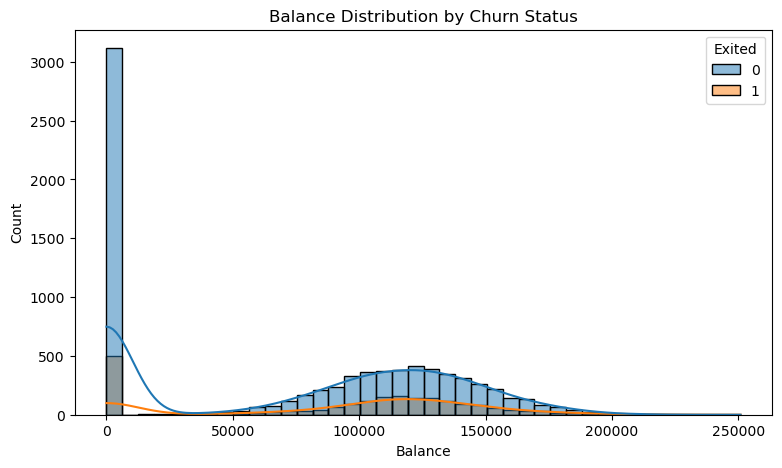

In [22]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Balance",
    hue="Exited",
    bins=40,
    kde=True
)

plt.title("Balance Distribution by Churn Status")

plt.show()

In [23]:
def mann_whitney_test(
    data,
    variable,
    target="Exited"
):
    
    retained = data.loc[
        data[target] == 0,
        variable
    ].dropna()
    
    churned = data.loc[
        data[target] == 1,
        variable
    ].dropna()
    
    statistic, p_value = mannwhitneyu(
        retained,
        churned,
        alternative="two-sided"
    )
    
    return {
        "Variable": variable,
        "Retained_Median": retained.median(),
        "Churned_Median": churned.median(),
        "U_Statistic": statistic,
        "p_value": p_value,
        "Significance": significance_label(p_value)
    }

In [24]:
balance_test = mann_whitney_test(
    df,
    "Balance"
)

balance_test

{'Variable': 'Balance',
 'Retained_Median': 92072.68,
 'Churned_Median': 109349.29,
 'U_Statistic': np.float64(6849444.5),
 'p_value': np.float64(1.1158399379149222e-28),
 'Significance': 'Significant'}

In [25]:
salary_test = mann_whitney_test(
    df,
    "EstimatedSalary"
)

salary_test

{'Variable': 'EstimatedSalary',
 'Retained_Median': 99645.04,
 'Churned_Median': 102460.84,
 'U_Statistic': np.float64(7969863.0),
 'p_value': np.float64(0.22705150930153783),
 'Significance': 'Not Significant'}

In [27]:
age_test = mann_whitney_test(
    df,
    "Age"
)

age_test

{'Variable': 'Age',
 'Retained_Median': 36.0,
 'Churned_Median': 45.0,
 'U_Statistic': np.float64(4345981.5),
 'p_value': np.float64(3.2104014319371675e-230),
 'Significance': 'Significant'}

In [28]:
credit_score_test = mann_whitney_test(
    df,
    "CreditScore"
)

credit_score_test

{'Variable': 'CreditScore',
 'Retained_Median': 653.0,
 'Churned_Median': 646.0,
 'U_Statistic': np.float64(8381083.0),
 'p_value': np.float64(0.01986866117272834),
 'Significance': 'Significant'}

In [29]:
tenure_test = mann_whitney_test(
    df,
    "Tenure"
)

tenure_test

{'Variable': 'Tenure',
 'Retained_Median': 5.0,
 'Churned_Median': 5.0,
 'U_Statistic': np.float64(8272055.5),
 'p_value': np.float64(0.16219376122918827),
 'Significance': 'Not Significant'}

In [30]:
rsi_test = mann_whitney_test(
    df,
    "Relationship_Strength_Index"
)

rsi_test

{'Variable': 'Relationship_Strength_Index',
 'Retained_Median': 65.0,
 'Churned_Median': 40.0,
 'U_Statistic': np.float64(10788972.0),
 'p_value': np.float64(1.2671673667079527e-118),
 'Significance': 'Significant'}

In [31]:
risk_test = mann_whitney_test(
    df,
    "Retention_Risk_Score_Adjusted"
)

risk_test

{'Variable': 'Retention_Risk_Score_Adjusted',
 'Retained_Median': 35.0,
 'Churned_Median': 65.0,
 'U_Statistic': np.float64(5373090.0),
 'p_value': np.float64(1.8555094626726638e-124),
 'Significance': 'Significant'}

In [32]:
numeric_test_results = pd.DataFrame([
    balance_test,
    salary_test,
    age_test,
    credit_score_test,
    tenure_test,
    rsi_test,
    risk_test
])

numeric_test_results

,Variable,Retained_Median,Churned_Median,U_Statistic,p_value,Significance
0,Balance,92072.68,109349.29,6849444.5,1.115840e-28,Significant
1,EstimatedSalary,99645.04,102460.84,7969863.0,2.270515e-01,Not Significant
2,Age,36.00,45.00,4345981.5,3.210401e-230,Significant
3,CreditScore,653.00,646.00,8381083.0,1.986866e-02,Significant
4,Tenure,5.00,5.00,8272055.5,1.621938e-01,Not Significant
5,Relationship_Strength_Index,65.00,40.00,10788972.0,1.267167e-118,Significant
6,Retention_Risk_Score_Adjusted,35.00,65.00,5373090.0,1.855509e-124,Significant


In [33]:
numeric_test_results[
    [
        "Variable",
        "Retained_Median",
        "Churned_Median",
        "p_value",
        "Significance"
    ]
].round(4)

,Variable,Retained_Median,Churned_Median,p_value,Significance
0,Balance,92072.68,109349.29,0.0000,Significant
1,EstimatedSalary,99645.04,102460.84,0.2271,Not Significant
2,Age,36.00,45.00,0.0000,Significant
3,CreditScore,653.00,646.00,0.0199,Significant
4,Tenure,5.00,5.00,0.1622,Not Significant
5,Relationship_Strength_Index,65.00,40.00,0.0000,Significant
6,Retention_Risk_Score_Adjusted,35.00,65.00,0.0000,Significant


In [34]:
r, p = pointbiserialr(
    df["Exited"],
    df["Relationship_Strength_Index"]
)

print("Correlation:", round(r, 4))
print("p-value:", p)
print(
    "Result:",
    significance_label(p)
)

Correlation: -0.2301
p-value: 2.9018286426014335e-120
Result: Significant


In [35]:
r, p = pointbiserialr(
    df["Exited"],
    df["Retention_Risk_Score_Adjusted"]
)

print("Correlation:", round(r, 4))
print("p-value:", p)
print(
    "Result:",
    significance_label(p)
)

Correlation: 0.2329
p-value: 3.036533326222305e-123
Result: Significant


In [36]:
categorical_tests = []

categorical_variables = [
    "Engagement_Status",
    "NumOfProducts",
    "Product_Depth_Group",
    "HasCrCard",
    "Geography",
    "Gender",
    "Final_Engagement_Segment",
    "Customer_Value_Segment",
    "High_Value_Disengaged"
]

for variable in categorical_variables:
    
    table = pd.crosstab(
        df[variable],
        df["Exited"]
    )
    
    chi2, p_value, dof, expected = chi2_contingency(
        table
    )
    
    categorical_tests.append({
        "Variable": variable,
        "Chi2": chi2,
        "p_value": p_value,
        "Cramers_V": cramers_v(table),
        "Significance": significance_label(p_value)
    })

categorical_test_results = pd.DataFrame(
    categorical_tests
)

categorical_test_results.round(4)

,Variable,Chi2,p_value,Cramers_V,Significance
0,Engagement_Status,242.9853,0.0000,0.1556,Significant
1,NumOfProducts,1503.6294,0.0000,0.3874,Significant
2,Product_Depth_Group,1494.6033,0.0000,0.3864,Significant
3,HasCrCard,0.4713,0.4924,0.0000,Not Significant
4,Geography,301.2553,0.0000,0.1730,Significant
5,Gender,112.9186,0.0000,0.1058,Significant
6,Final_Engagement_Segment,1754.0695,0.0000,0.4184,Significant
7,Customer_Value_Segment,264.5094,0.0000,0.1617,Significant
8,High_Value_Disengaged,88.9406,0.0000,0.0938,Significant


In [37]:
significant_categorical = (
    categorical_test_results[
        categorical_test_results["p_value"] < 0.05
    ]
    .sort_values("Cramers_V", ascending=False)
)

significant_categorical.round(4)

,Variable,Chi2,p_value,Cramers_V,Significance
6,Final_Engagement_Segment,1754.0695,0.0,0.4184,Significant
1,NumOfProducts,1503.6294,0.0,0.3874,Significant
2,Product_Depth_Group,1494.6033,0.0,0.3864,Significant
4,Geography,301.2553,0.0,0.1730,Significant
7,Customer_Value_Segment,264.5094,0.0,0.1617,Significant
0,Engagement_Status,242.9853,0.0,0.1556,Significant
5,Gender,112.9186,0.0,0.1058,Significant
8,High_Value_Disengaged,88.9406,0.0,0.0938,Significant


In [38]:
categorical_test_results["Adjusted_p_value"] = (
    categorical_test_results["p_value"]
    * len(categorical_test_results)
)

categorical_test_results["Adjusted_p_value"] = (
    categorical_test_results["Adjusted_p_value"]
    .clip(upper=1)
)

categorical_test_results["Adjusted_Significance"] = (
    categorical_test_results["Adjusted_p_value"]
    < 0.05
)

categorical_test_results.round(4)

,Variable,Chi2,p_value,Cramers_V,Significance,Adjusted_p_value,Adjusted_Significance
0,Engagement_Status,242.9853,0.0000,0.1556,Significant,0.0,True
1,NumOfProducts,1503.6294,0.0000,0.3874,Significant,0.0,True
2,Product_Depth_Group,1494.6033,0.0000,0.3864,Significant,0.0,True
3,HasCrCard,0.4713,0.4924,0.0000,Not Significant,1.0,False
4,Geography,301.2553,0.0000,0.1730,Significant,0.0,True
5,Gender,112.9186,0.0000,0.1058,Significant,0.0,True
6,Final_Engagement_Segment,1754.0695,0.0000,0.4184,Significant,0.0,True
7,Customer_Value_Segment,264.5094,0.0000,0.1617,Significant,0.0,True
8,High_Value_Disengaged,88.9406,0.0000,0.0938,Significant,0.0,True


In [39]:
statistical_evidence = pd.DataFrame({
    "Hypothesis": [
        "Engagement status is associated with churn",
        "Product count is associated with churn",
        "Credit-card ownership is associated with churn",
        "High-value disengagement is associated with churn",
        "Relationship Strength differs by churn status",
        "Retention risk score differs by churn status"
    ],
    
    "Test": [
        "Chi-Square",
        "Chi-Square",
        "Chi-Square",
        "Chi-Square",
        "Mann-Whitney U",
        "Mann-Whitney U"
    ]
})

statistical_evidence

,Hypothesis,Test
0,Engagement status is associated with churn,Chi-Square
1,Product count is associated with churn,Chi-Square
2,Credit-card ownership is associated with churn,Chi-Square
3,High-value disengagement is associated with churn,Chi-Square
4,Relationship Strength differs by churn status,Mann-Whitney U
5,Retention risk score differs by churn status,Mann-Whitney U


In [40]:
print("Engagement p-value:", engagement_table)

Engagement p-value: Exited                0     1
Engagement_Status            
Active             4416   735
Inactive           3547  1302


In [41]:
def chi_square_result(
    data,
    variable,
    target="Exited"
):
    
    table = pd.crosstab(
        data[variable],
        data[target]
    )
    
    chi2, p_value, dof, expected = chi2_contingency(
        table
    )
    
    return {
        "Variable": variable,
        "Test": "Chi-Square",
        "Statistic": chi2,
        "p_value": p_value,
        "Effect_Size": cramers_v(table),
        "Significance": significance_label(p_value)
    }

In [42]:
important_categorical = [
    "Engagement_Status",
    "NumOfProducts",
    "HasCrCard",
    "High_Value_Disengaged",
    "Final_Engagement_Segment",
    "Customer_Value_Segment"
]

important_results = pd.DataFrame([
    chi_square_result(df, col)
    for col in important_categorical
])

important_results.round(4)

,Variable,Test,Statistic,p_value,Effect_Size,Significance
0,Engagement_Status,Chi-Square,242.9853,0.0000,0.1556,Significant
1,NumOfProducts,Chi-Square,1503.6294,0.0000,0.3874,Significant
2,HasCrCard,Chi-Square,0.4713,0.4924,0.0000,Not Significant
3,High_Value_Disengaged,Chi-Square,88.9406,0.0000,0.0938,Significant
4,Final_Engagement_Segment,Chi-Square,1754.0695,0.0000,0.4184,Significant
5,Customer_Value_Segment,Chi-Square,264.5094,0.0000,0.1617,Significant


In [43]:
final_validation = important_results[
    [
        "Variable",
        "Test",
        "Statistic",
        "p_value",
        "Effect_Size",
        "Significance"
    ]
].copy()

final_validation.round(4)

,Variable,Test,Statistic,p_value,Effect_Size,Significance
0,Engagement_Status,Chi-Square,242.9853,0.0000,0.1556,Significant
1,NumOfProducts,Chi-Square,1503.6294,0.0000,0.3874,Significant
2,HasCrCard,Chi-Square,0.4713,0.4924,0.0000,Not Significant
3,High_Value_Disengaged,Chi-Square,88.9406,0.0000,0.0938,Significant
4,Final_Engagement_Segment,Chi-Square,1754.0695,0.0000,0.4184,Significant
5,Customer_Value_Segment,Chi-Square,264.5094,0.0000,0.1617,Significant


In [44]:
final_validation.to_csv(
    "Statistical_Validation_Categorical.csv",
    index=False
)

numeric_test_results.to_csv(
    "Statistical_Validation_Numerical.csv",
    index=False
)

In [45]:
df.groupby("NumOfProducts").agg(
    Customers=("CustomerId", "count"),
    Churned=("Exited", "sum"),
    Churn_Rate=("Exited", "mean")
)

,Customers,Churned,Churn_Rate
NumOfProducts,,,
1,5084,1409,0.277144
2,4590,348,0.075817
3,266,220,0.827068
4,60,60,1.000000


In [46]:
df.to_csv(
    "European_Bank_Statistically_Validated.csv",
    index=False
)

print(
    "✅ Step 7 statistical validation completed."
)

✅ Step 7 statistical validation completed.
